# Notebook 19 — Conditional Diffusion + FiLM (A2 CNN + B1)

**Goal**: Inverse design via conditional diffusion — given a **1000-point target spectrum**, generate **20 design parameters** that reproduce it.

| Aspect | Detail |
|--------|--------|
| **Forward surrogate** | A2 CNN (frozen, from Notebook 18) |
| **Inverse method** | DDPM conditioned on full spectrum via FiLM |
| **Spectrum encoder** | 1D-CNN → 512-dim embedding |
| **Diffusion backbone** | 4 × FiLM residual blocks (hidden_dim=512) |
| **Timesteps** | 200, cosine β schedule |
| **Loss** | Noise MSE + ramped physics-guided spectral MSE |
| **Key advantage** | Generates diverse candidate solutions (multi-modal) |

In [1]:
# ============================================================
# Cell 1 — Imports & Configuration
# ============================================================
import sys, os, time, pickle, math, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

sys.path.insert(0, os.path.abspath('../src'))
from Theoretical_model import calculate_acoustic_properties
from physics_guided_CD_FiLM import PARAM_RANGES, validate_and_clip_parameters

# ---------- Device ----------
assert torch.cuda.is_available(), 'CUDA required'
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')
print(f'Device: {torch.cuda.get_device_name()}')

# ---------- Reproducibility ----------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------- Paths ----------
DATA_PATH      = '../data/Data/lhs_data_full_spectrum.npz'
MODEL_DIR      = '../models'
SURROGATE_PATH = os.path.join(MODEL_DIR, 'forward_surrogate_cnn.pth')
SCALER_PATH    = os.path.join(MODEL_DIR, 'forward_surrogate_cnn_scaler.pkl')
DIFFUSION_PATH = os.path.join(MODEL_DIR, 'inverse_diffusion_a2.pth')
DIFF_SCALER    = os.path.join(MODEL_DIR, 'inverse_diffusion_a2_scaler.pkl')

# ---------- Hyper-parameters ----------
BATCH_SIZE    = 256
EPOCHS        = 50
LR_INIT       = 1e-3
LR_MIN        = 1e-5
HIDDEN_DIM    = 512
NUM_PARAMS    = 20
NUM_FREQ      = 1000
NUM_TIMESTEPS = 200
EMA_DECAY     = 0.999
PHYS_LAMBDA_MAX = 0.1
PHYS_RAMP_EPOCHS = 15
NUM_CANDIDATES = 20    # candidates per target at inference

PARAM_NAMES = ['d1','d2','d3','d4','d5','d6','d7','d8','d9','d10',
               'm2','m3','m5','m6','m8','m9','rho','eta','E','nu']

print('\n✓ Imports & config ready')

Device: NVIDIA GeForce RTX 2060 SUPER

✓ Imports & config ready


## Load Data

In [2]:
# ============================================================
# Cell 2 — Load Data & Split
# ============================================================
print('Loading NPZ …')
t0 = time.time()
raw = np.load(DATA_PATH)
params_all  = raw['params'].astype(np.float32)
spectra_all = raw['spectra'].astype(np.float32)
frequencies = raw['frequencies']
print(f'  Loaded in {time.time()-t0:.1f}s')

X_train, X_temp, Y_train, Y_temp = train_test_split(
    params_all, spectra_all, test_size=0.2, random_state=SEED)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=SEED)

print(f'  Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

scaler_x = MinMaxScaler()
X_train_n = scaler_x.fit_transform(X_train).astype(np.float32)
X_val_n   = scaler_x.transform(X_val).astype(np.float32)
X_test_n  = scaler_x.transform(X_test).astype(np.float32)

print('✓ Data ready')

Loading NPZ …
  Loaded in 53.9s
  Train: 800,000  Val: 100,000  Test: 100,000
✓ Data ready


In [3]:
# ============================================================
# Cell 3 — DataLoaders (input=normalised params, condition=spectra)
# ============================================================
def make_loader(params_norm, spectra, batch_size, shuffle=True):
    ds = TensorDataset(torch.tensor(params_norm, dtype=torch.float32),
                       torch.tensor(spectra, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=True)

train_loader = make_loader(X_train_n, Y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val_n,   Y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test_n,  Y_test,  BATCH_SIZE, shuffle=False)

print(f'✓ DataLoaders — {len(train_loader)} train batches')

✓ DataLoaders — 3125 train batches


## Load Forward Surrogate (A2 CNN, Frozen)

In [4]:
# ============================================================
# Cell 4 — Load Forward Surrogate (A2 CNN)
# ============================================================
class ForwardSurrogateCNN(nn.Module):
    def __init__(self, in_dim=20, out_dim=1000):
        super().__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.stem = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256), nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(256, 128 * 32),
            nn.BatchNorm1d(128 * 32), nn.LeakyReLU(0.01, inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(64), nn.LeakyReLU(0.01, inplace=True),
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(32), nn.LeakyReLU(0.01, inplace=True),
            nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(16), nn.LeakyReLU(0.01, inplace=True),
            nn.ConvTranspose1d(16, 8, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(8), nn.LeakyReLU(0.01, inplace=True),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 512, 1024),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Linear(1024, out_dim),
            nn.Sigmoid(),
        )
    def forward(self, x):
        h = self.stem(x)
        h = h.view(-1, 128, 32)
        h = self.decoder(h)
        return self.head(h)

ckpt_surr = torch.load(SURROGATE_PATH, map_location=device, weights_only=False)
arch = ckpt_surr['architecture']
surrogate = ForwardSurrogateCNN(
    in_dim=arch['in_dim'], out_dim=arch['out_dim'],
).to(device)
surrogate.load_state_dict(ckpt_surr['model_state_dict'])
surrogate.eval()
for p in surrogate.parameters():
    p.requires_grad = False

print(f'✓ Forward surrogate A2 CNN loaded (test MSE = {ckpt_surr["test_metrics"]["spectral_mse"]:.2e})')

✓ Forward surrogate A2 CNN loaded (test MSE = 3.90e-05)


## Diffusion Model Architecture

```
Noisy params x_t (20) ──┐
                         ├──→ Input Projection (20→512)
Timestep t   ──→ SinEmb ─┤
                         ├──→ cond = time_emb + spec_emb  (512)
Spectrum (1000) ─→ CNN  ─┘
                         │
                    4 × FiLM Block (512)
                         │
                    Output (512→20)  [zero-init]
                         │
                    Predicted noise ε̂
```

In [5]:
# ============================================================
# Cell 5 — Diffusion Model Components
# ============================================================

# --- Sinusoidal Positional Embedding ---
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

# --- Spectrum Encoder (1D-CNN) ---
class SpectrumEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32,  kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64), nn.SiLU(inplace=True),
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(128), nn.SiLU(inplace=True),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Sequential(nn.Linear(128, embed_dim), nn.SiLU(inplace=True))
    def forward(self, spectrum):
        x = spectrum.unsqueeze(1)  # (B,1,1000)
        x = self.conv(x).squeeze(-1)
        return self.fc(x)

# --- FiLM Block ---
class FiLMBlock(nn.Module):
    def __init__(self, hidden_dim, cond_dim, dropout=0.1):
        super().__init__()
        self.fc1  = nn.Linear(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.film = nn.Linear(cond_dim, hidden_dim * 2)  # γ and β
        self.fc2  = nn.Linear(hidden_dim, hidden_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, cond):
        residual = x
        x = self.fc1(x)
        x = self.norm(x)
        # FiLM modulation
        gamma_beta = self.film(cond)
        gamma, beta = gamma_beta.chunk(2, dim=-1)
        x = x * (1 + gamma) + beta
        x = F.silu(x)
        x = self.drop(x)
        x = self.fc2(x)
        return x + residual

# --- Full Diffusion Network ---
class ConditionalDiffusionNet(nn.Module):
    def __init__(self, param_dim=20, hidden_dim=512, num_blocks=4):
        super().__init__()
        # Time embedding
        self.time_emb = nn.Sequential(
            SinusoidalPosEmb(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.SiLU(),
        )
        # Spectrum embedding
        self.spec_emb = SpectrumEncoder(embed_dim=hidden_dim)

        # Input projection
        self.input_proj = nn.Linear(param_dim, hidden_dim)

        # FiLM backbone
        self.blocks = nn.ModuleList([
            FiLMBlock(hidden_dim, hidden_dim, dropout=0.1)
            for _ in range(num_blocks)
        ])

        # Output
        self.out = nn.Sequential(
            nn.LayerNorm(hidden_dim), nn.SiLU(),
            nn.Linear(hidden_dim, param_dim)
        )
        # Zero-initialise output layer (diffusion best practice)
        nn.init.zeros_(self.out[-1].weight)
        nn.init.zeros_(self.out[-1].bias)

    def forward(self, x_t, t, spectrum):
        """
        x_t:      (B, 20)   noisy params
        t:        (B,)      timesteps
        spectrum: (B, 1000) conditioning spectrum
        """
        t_emb = self.time_emb(t.float())        # (B, 512)
        s_emb = self.spec_emb(spectrum)          # (B, 512)
        cond  = t_emb + s_emb                    # additive fusion

        h = self.input_proj(x_t)
        for block in self.blocks:
            h = block(h, cond)
        return self.out(h)


diff_net = ConditionalDiffusionNet(param_dim=NUM_PARAMS, hidden_dim=HIDDEN_DIM).to(device)
total_p = sum(p.numel() for p in diff_net.parameters())
print(f'✓ ConditionalDiffusionNet — {total_p:,} parameters')

✓ ConditionalDiffusionNet — 4,855,700 parameters


## Diffusion Scheduler (Cosine β Schedule) & EMA

In [6]:
# ============================================================
# Cell 6 — Cosine Beta Schedule, Diffusion Utilities & EMA
# ============================================================
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clamp(betas, 0.0001, 0.9999)

betas = cosine_beta_schedule(NUM_TIMESTEPS).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod     = torch.sqrt(alphas_cumprod)
sqrt_one_minus_ac       = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas       = torch.sqrt(1.0 / alphas)
posterior_variance       = betas * (1.0 - torch.cat([torch.tensor([1.0], device=device),
                                                      alphas_cumprod[:-1]])) / (1.0 - alphas_cumprod)

def q_sample(x_0, t, noise=None):
    """Forward diffusion: add noise to x_0 at timestep t."""
    if noise is None:
        noise = torch.randn_like(x_0)
    s_ac = sqrt_alphas_cumprod[t].unsqueeze(-1)
    s_om = sqrt_one_minus_ac[t].unsqueeze(-1)
    return s_ac * x_0 + s_om * noise, noise

def predict_x0_from_noise(x_t, t, noise_pred):
    """Reconstruct x_0 from noise prediction."""
    s_ac = sqrt_alphas_cumprod[t].unsqueeze(-1)
    s_om = sqrt_one_minus_ac[t].unsqueeze(-1)
    return (x_t - s_om * noise_pred) / (s_ac + 1e-8)

print(f'✓ Cosine β schedule — {NUM_TIMESTEPS} steps, β ∈ [{betas.min():.4f}, {betas.max():.4f}]')

# --- EMA ---
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k, v in model.state_dict().items()}

    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v.detach()

    def apply(self, model):
        model.load_state_dict(self.shadow)

    def state_dict(self):
        return self.shadow

ema = EMA(diff_net, decay=EMA_DECAY)
print(f'✓ EMA initialised (decay={EMA_DECAY})')

✓ Cosine β schedule — 200 steps, β ∈ [0.0003, 0.9999]
✓ EMA initialised (decay=0.999)


## Loss, Optimizer & Scheduler

**Loss:** $L = L_{\text{noise}} + \lambda(e) \cdot L_{\text{spectral}}$

- $L_{\text{noise}} = \text{MSE}(\hat{\epsilon}, \epsilon)$ — standard DDPM
- $L_{\text{spectral}}$ — reconstruct $\hat{x}_0$ from noise pred, pass through frozen A2 CNN surrogate, MSE with target spectrum
- $\lambda$ ramps linearly 0 → 0.1 over first 15 epochs
- Frequency weights: 2× for first 400 Hz, normalised so mean=1

In [7]:
# ============================================================
# Cell 7 — Loss, Optimizer, Scheduler
# ============================================================
def build_freq_weights(num_freq=1000, low_cutoff=400, low_weight=2.0, device='cpu'):
    w = torch.ones(num_freq, device=device)
    w[:low_cutoff] = low_weight
    return w / w.mean()

freq_w = build_freq_weights(device=device)

optimizer = optim.Adam(diff_net.parameters(), lr=LR_INIT, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR_MIN)

print('✓ Optimizer (Adam lr=1e-3→1e-5) & CosineAnnealing scheduler ready')

✓ Optimizer (Adam lr=1e-3→1e-5) & CosineAnnealing scheduler ready


## Training Loop

In [8]:
# ============================================================
# Cell 8 — Training (50 epochs)
# ============================================================
train_losses = []
val_losses   = []
best_val = float('inf')
best_state = None

print(f'Training {EPOCHS} epochs …\n')
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    # Physics loss ramp
    phys_lambda = min(PHYS_LAMBDA_MAX, PHYS_LAMBDA_MAX * epoch / PHYS_RAMP_EPOCHS)

    # ---------- Train ----------
    diff_net.train()
    ep_loss = 0.0
    for params_b, spec_b in train_loader:
        params_b = params_b.to(device)  # normalised params (x_0)
        spec_b   = spec_b.to(device)    # condition spectrum
        B = params_b.size(0)

        # Sample random timesteps
        t = torch.randint(0, NUM_TIMESTEPS, (B,), device=device)
        noise = torch.randn_like(params_b)
        x_t, _ = q_sample(params_b, t, noise)

        # Predict noise
        noise_pred = diff_net(x_t, t, spec_b)
        L_noise = F.mse_loss(noise_pred, noise)

        # Physics-guided spectral loss
        if phys_lambda > 0:
            x0_hat = predict_x0_from_noise(x_t, t, noise_pred)
            x0_hat = x0_hat.clamp(0, 1)  # keep in normalised range
            spec_pred = surrogate(x0_hat)
            L_spec = ((spec_pred - spec_b)**2 * freq_w).mean()
        else:
            L_spec = torch.tensor(0.0, device=device)

        loss = L_noise + phys_lambda * L_spec

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diff_net.parameters(), max_norm=1.0)
        optimizer.step()
        ema.update(diff_net)

        ep_loss += loss.item() * B

    train_losses.append(ep_loss / len(train_loader.dataset))

    # ---------- Validate ----------
    diff_net.eval()
    v_loss = 0.0
    with torch.no_grad():
        for params_b, spec_b in val_loader:
            params_b = params_b.to(device)
            spec_b   = spec_b.to(device)
            B = params_b.size(0)
            t = torch.randint(0, NUM_TIMESTEPS, (B,), device=device)
            noise = torch.randn_like(params_b)
            x_t, _ = q_sample(params_b, t, noise)
            noise_pred = diff_net(x_t, t, spec_b)
            v_loss += F.mse_loss(noise_pred, noise).item() * B

    val_losses.append(v_loss / len(val_loader.dataset))
    scheduler.step()

    if val_losses[-1] < best_val:
        best_val   = val_losses[-1]
        best_state = {k: v.cpu().clone() for k, v in diff_net.state_dict().items()}
        tag = ' ★'
    else:
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        lr_now = scheduler.get_last_lr()[0]
        print(f'  Epoch {epoch:3d}/{EPOCHS}  '
              f'train {train_losses[-1]:.6f}  val(noise) {val_losses[-1]:.6f}  '
              f'λ_phys {phys_lambda:.3f}  lr {lr_now:.2e}{tag}')

elapsed = time.time() - t_start
print(f'\n✓ Training complete in {elapsed/60:.1f} min  —  best val noise loss = {best_val:.6f}')

# Apply EMA weights for inference
ema.apply(diff_net)
diff_net.to(device)
print('  EMA weights applied')

Training 50 epochs …

  Epoch   1/50  train 0.207022  val(noise) 0.197839  λ_phys 0.007  lr 9.99e-04 ★
  Epoch   5/50  train 0.191070  val(noise) 0.193946  λ_phys 0.033  lr 9.76e-04
  Epoch  10/50  train 0.188994  val(noise) 0.205811  λ_phys 0.067  lr 9.05e-04
  Epoch  15/50  train 0.187520  val(noise) 0.188912  λ_phys 0.100  lr 7.96e-04
  Epoch  20/50  train 0.186820  val(noise) 0.187625  λ_phys 0.100  lr 6.58e-04
  Epoch  25/50  train 0.185377  val(noise) 0.186943  λ_phys 0.100  lr 5.05e-04
  Epoch  30/50  train 0.184610  val(noise) 0.200901  λ_phys 0.100  lr 3.52e-04
  Epoch  35/50  train 0.182989  val(noise) 0.190511  λ_phys 0.100  lr 2.14e-04
  Epoch  40/50  train 0.182363  val(noise) 0.180214  λ_phys 0.100  lr 1.05e-04 ★
  Epoch  45/50  train 0.180793  val(noise) 0.177639  λ_phys 0.100  lr 3.42e-05 ★
  Epoch  50/50  train 0.180998  val(noise) 0.179332  λ_phys 0.100  lr 1.00e-05

✓ Training complete in 78.4 min  —  best val noise loss = 0.177639
  EMA weights applied


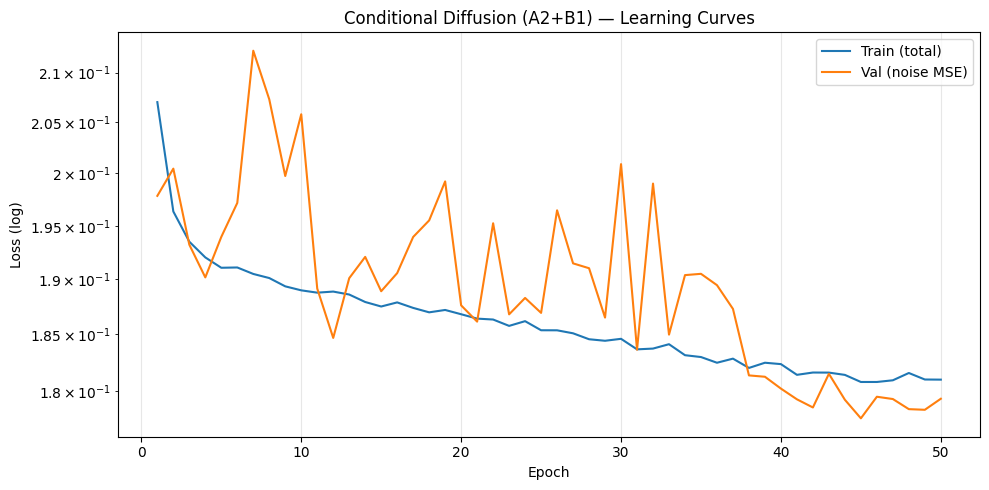

In [9]:
# ============================================================
# Cell 9 — Learning Curves
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(range(1, EPOCHS+1), train_losses, label='Train (total)')
ax.semilogy(range(1, EPOCHS+1), val_losses,   label='Val (noise MSE)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log)')
ax.set_title('Conditional Diffusion (A2+B1) — Learning Curves')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Sampling (Reverse Diffusion)

In [10]:
# ============================================================
# Cell 10 — DDPM Sampling Function
# ============================================================
@torch.no_grad()
def sample_params(model, spectrum, num_candidates=20, clip_every=10):
    """
    Reverse diffusion: generate candidate parameter sets for a target spectrum.

    Args:
        model:          diffusion network (eval mode)
        spectrum:        (1000,) target absorption spectrum (tensor on device)
        num_candidates:  how many candidates to generate
        clip_every:      enforce constraints every N steps

    Returns:
        candidates: (num_candidates, 20) normalised params
    """
    model.eval()
    spec_cond = spectrum.unsqueeze(0).expand(num_candidates, -1)   # (C, 1000)
    x = torch.randn(num_candidates, NUM_PARAMS, device=device)     # start from noise

    for i in reversed(range(NUM_TIMESTEPS)):
        t = torch.full((num_candidates,), i, device=device, dtype=torch.long)
        noise_pred = model(x, t, spec_cond)

        alpha_t   = alphas[i]
        ac_t      = alphas_cumprod[i]
        beta_t    = betas[i]

        # DDPM update
        x = sqrt_recip_alphas[i] * (x - beta_t / sqrt_one_minus_ac[i] * noise_pred)

        if i > 0:
            noise = torch.randn_like(x)
            x = x + torch.sqrt(posterior_variance[i]) * noise

        # Periodic constraint enforcement
        if i % clip_every == 0:
            x = x.clamp(0, 1)

    return x.clamp(0, 1)


def select_best_candidate(candidates_norm, target_spectrum, surrogate_fn, scaler):
    """
    Select the candidate whose surrogate-predicted spectrum best matches the target.
    Returns: (best_params_raw, best_spec_pred, best_mse)
    """
    with torch.no_grad():
        spec_pred = surrogate_fn(candidates_norm)  # (C, 1000)
    target_exp = target_spectrum.unsqueeze(0).expand_as(spec_pred)
    mse_per = ((spec_pred - target_exp)**2).mean(dim=1)  # (C,)
    best_idx = mse_per.argmin().item()

    best_norm = candidates_norm[best_idx].cpu().numpy()
    best_raw  = scaler.inverse_transform(best_norm.reshape(1, -1)).flatten()
    best_spec = spec_pred[best_idx].cpu().numpy()
    return best_raw, best_spec, mse_per[best_idx].item()

print('✓ Sampling functions defined')

✓ Sampling functions defined


## Test Metrics (Single Sample)

In [11]:
# ============================================================
# Cell 11 — Test Metrics (single sample via prior sampling)
# ============================================================
diff_net.eval()
all_spec_mse = []

with torch.no_grad():
    for params_b, spec_b in test_loader:
        spec_b = spec_b.to(device)
        B = spec_b.size(0)
        # Generate 1 candidate per target via full reverse diffusion
        spec_cond = spec_b  # (B, 1000)
        x = torch.randn(B, NUM_PARAMS, device=device)
        for i in reversed(range(NUM_TIMESTEPS)):
            t = torch.full((B,), i, device=device, dtype=torch.long)
            noise_pred = diff_net(x, t, spec_cond)
            x = sqrt_recip_alphas[i] * (x - betas[i] / sqrt_one_minus_ac[i] * noise_pred)
            if i > 0:
                x = x + torch.sqrt(posterior_variance[i]) * torch.randn_like(x)
            if i % 10 == 0:
                x = x.clamp(0, 1)
        x = x.clamp(0, 1)
        recon_spec = surrogate(x)
        mse = ((recon_spec - spec_b)**2).mean(dim=1)
        all_spec_mse.append(mse.cpu().numpy())

spec_mse_arr = np.concatenate(all_spec_mse)
print('═══════════════════════════════════════════')
print('  TEST METRICS — Diffusion (A2+B1), single sample')
print('═══════════════════════════════════════════')
print(f'  Mean spectral MSE   : {spec_mse_arr.mean():.6e}')
print(f'  Median spectral MSE : {np.median(spec_mse_arr):.6e}')
for p in [90, 95, 99]:
    print(f'  {p}th pctile MSE    : {np.percentile(spec_mse_arr, p):.6e}')
print('═══════════════════════════════════════════')

═══════════════════════════════════════════
  TEST METRICS — Diffusion (A2+B1), single sample
═══════════════════════════════════════════
  Mean spectral MSE   : 7.077773e-04
  Median spectral MSE : 1.141547e-04
  90th pctile MSE    : 1.108834e-03
  95th pctile MSE    : 2.587663e-03
  99th pctile MSE    : 1.210978e-02
═══════════════════════════════════════════


## Best-of-20 Test (200 Targets)

In [12]:
# ============================================================
# Cell 12 — Best-of-20 Test (200 targets)
# ============================================================
np.random.seed(123)
bon_idx = np.random.choice(len(X_test), 200, replace=False)

bon_mse = []
diff_net.eval()
with torch.no_grad():
    for idx in bon_idx:
        spec_t = torch.tensor(Y_test[idx], dtype=torch.float32, device=device)
        candidates = sample_params(diff_net, spec_t, num_candidates=NUM_CANDIDATES)
        specs = surrogate(candidates)
        mses  = ((specs - spec_t.unsqueeze(0))**2).mean(dim=1)
        bon_mse.append(mses.min().item())

bon_mse = np.array(bon_mse)
print(f'Best-of-{NUM_CANDIDATES} test (200 targets):')
print(f'  Mean MSE : {bon_mse.mean():.6e}')
print(f'  Median   : {np.median(bon_mse):.6e}')
print(f'  95th pct : {np.percentile(bon_mse, 95):.6e}')

Best-of-20 test (200 targets):
  Mean MSE : 7.042548e-05
  Median   : 9.237863e-06
  95th pct : 2.730663e-04


## Overlay: 6 Spectra

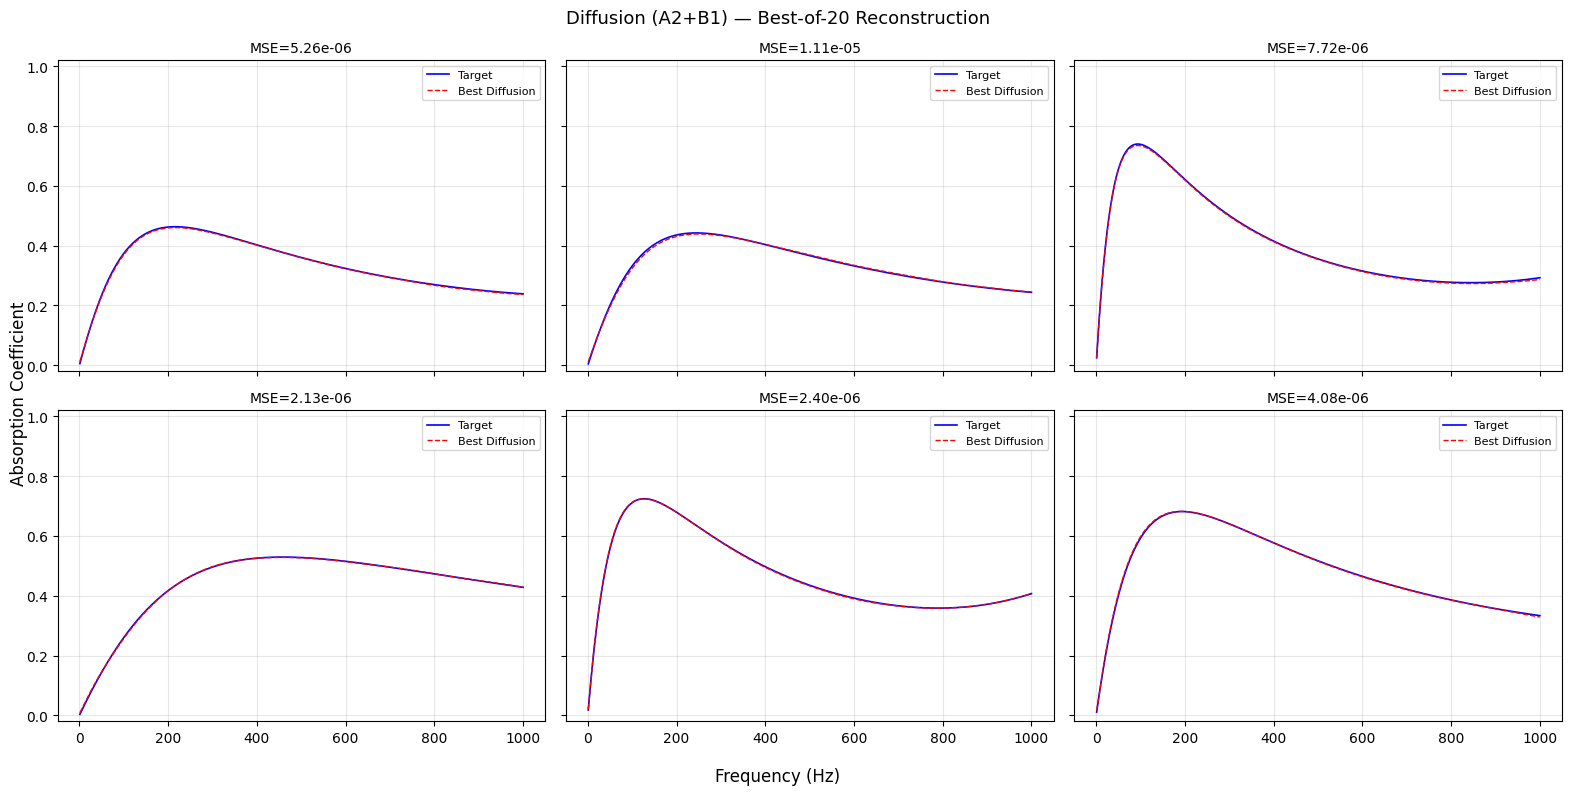

In [13]:
# ============================================================
# Cell 13 — Overlay: 6 Spectra
# ============================================================
np.random.seed(77)
show_idx = np.random.choice(len(X_test), 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
diff_net.eval()
for ax, idx in zip(axes.flat, show_idx):
    target = Y_test[idx]
    spec_t = torch.tensor(target, dtype=torch.float32, device=device)
    with torch.no_grad():
        candidates = sample_params(diff_net, spec_t, num_candidates=NUM_CANDIDATES)
        specs = surrogate(candidates)
        mses  = ((specs - spec_t.unsqueeze(0))**2).mean(dim=1)
        best  = specs[mses.argmin()].cpu().numpy()

    ax.plot(frequencies, target, 'b-',  lw=1.2, label='Target')
    ax.plot(frequencies, best,   'r--', lw=1.0, label='Best Diffusion')
    ax.set_title(f'MSE={mses.min().item():.2e}', fontsize=10)
    ax.set_ylim(-0.02, 1.02); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.supxlabel('Frequency (Hz)')
fig.supylabel('Absorption Coefficient')
fig.suptitle('Diffusion (A2+B1) — Best-of-20 Reconstruction', fontsize=13)
plt.tight_layout(); plt.show()

## TMM Validation

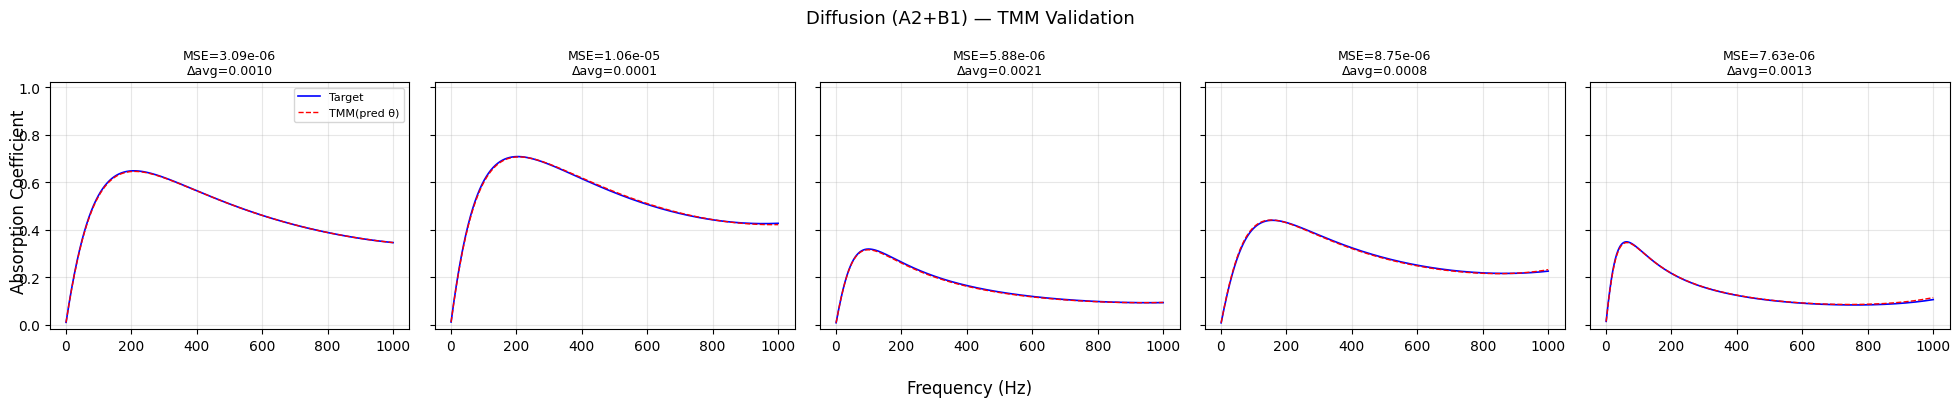


  TMM Validation:
    Sample  86155  MSE=3.0926e-06  Δavg=0.0010
    Sample  29633  MSE=1.0590e-05  Δavg=0.0001
    Sample  67710  MSE=5.8770e-06  Δavg=0.0021
    Sample  62348  MSE=8.7536e-06  Δavg=0.0008
    Sample  98787  MSE=7.6289e-06  Δavg=0.0013
  Mean TMM MSE: 7.1884e-06


In [14]:
# ============================================================
# Cell 14 — TMM Validation (5 test samples)
# ============================================================
NUM_TMM = 5
np.random.seed(99)
tmm_idx = np.random.choice(len(X_test), NUM_TMM, replace=False)

fig, axes = plt.subplots(1, NUM_TMM, figsize=(20, 4), sharex=True, sharey=True)
tmm_results = []

for ax, idx in zip(axes, tmm_idx):
    target = Y_test[idx]
    spec_t = torch.tensor(target, dtype=torch.float32, device=device)

    # Generate candidates
    candidates = sample_params(diff_net, spec_t, num_candidates=NUM_CANDIDATES)
    best_raw, best_spec_surr, best_mse_surr = select_best_candidate(
        candidates, spec_t, surrogate, scaler_x)

    # Clip to valid range
    best_raw = validate_and_clip_parameters(best_raw.reshape(1, -1)).flatten()

    # Real TMM
    param_dict = {
        'rho': float(best_raw[16]), 'eta': float(best_raw[17]),
        'E':   float(best_raw[18]), 'nu':  float(best_raw[19]),
        'W':   2000.0,
        'd':   [float(best_raw[i]) for i in range(10)],
        'm':   {2: float(best_raw[10]), 3: float(best_raw[11]),
                5: float(best_raw[12]), 6: float(best_raw[13]),
                8: float(best_raw[14]), 9: float(best_raw[15])}
    }
    _, alpha_tmm, _, _ = calculate_acoustic_properties(param_dict)

    mse_tmm = np.mean((alpha_tmm - target)**2)
    avg_err = abs(alpha_tmm.mean() - target.mean())
    tmm_results.append({'idx': idx, 'mse': mse_tmm, 'avg_err': avg_err})

    ax.plot(frequencies, target,    'b-',  lw=1.2, label='Target')
    ax.plot(frequencies, alpha_tmm, 'r--', lw=1.0, label='TMM(pred θ)')
    ax.set_title(f'MSE={mse_tmm:.2e}\nΔavg={avg_err:.4f}', fontsize=9)
    ax.set_ylim(-0.02, 1.02); ax.grid(True, alpha=0.3)
    if idx == tmm_idx[0]: ax.legend(fontsize=8)

fig.supxlabel('Frequency (Hz)')
fig.supylabel('Absorption Coefficient')
fig.suptitle('Diffusion (A2+B1) — TMM Validation', fontsize=13)
plt.tight_layout(); plt.show()

print('\n  TMM Validation:')
for r in tmm_results:
    print(f'    Sample {r["idx"]:6d}  MSE={r["mse"]:.4e}  Δavg={r["avg_err"]:.4f}')
print(f'  Mean TMM MSE: {np.mean([r["mse"] for r in tmm_results]):.4e}')

## Multi-Modality Demonstration

Generate multiple candidates for a single target to show the diffusion model produces diverse solutions.

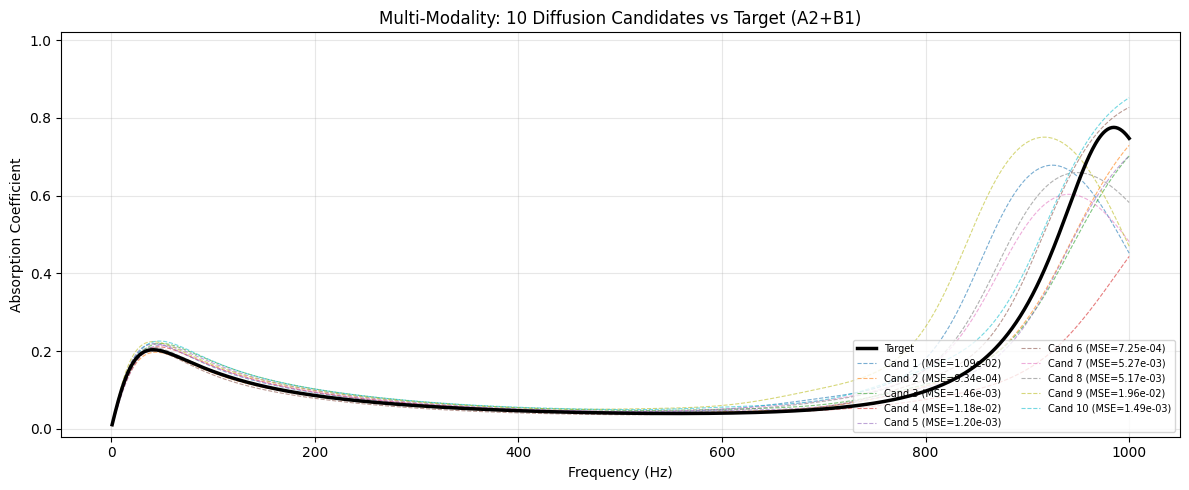


Parameter diversity (std across 10 candidates):
  d1   : std = 4.3976
  d2   : std = 4.9295
  d3   : std = 4.7154
  d4   : std = 4.7280
  d5   : std = 4.6277
  d6   : std = 4.9756
  d7   : std = 4.6377
  d8   : std = 6.0263
  d9   : std = 4.1189
  d10  : std = 4.5773
  m2   : std = 582.1873
  m3   : std = 442.1643
  m5   : std = 629.6466
  m6   : std = 438.9343
  m8   : std = 357.5261
  m9   : std = 423.3626
  rho  : std = 136.7696
  eta  : std = 0.0075
  E    : std = 6677292.0000
  nu   : std = 0.0234


In [15]:
# ============================================================
# Cell 15 — Multi-Modality: 10 Candidates for 1 Target
# ============================================================
np.random.seed(42)
demo_idx = np.random.choice(len(X_test), 1)[0]
target = Y_test[demo_idx]
spec_t = torch.tensor(target, dtype=torch.float32, device=device)

candidates = sample_params(diff_net, spec_t, num_candidates=10)
cand_raw = scaler_x.inverse_transform(candidates.cpu().numpy())  # (10, 20)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(frequencies, target, 'k-', lw=2.5, label='Target', zorder=10)

for i in range(10):
    with torch.no_grad():
        spec_i = surrogate(candidates[i:i+1]).cpu().numpy().flatten()
    mse_i = np.mean((spec_i - target)**2)
    ax.plot(frequencies, spec_i, '--', lw=0.8, alpha=0.6, label=f'Cand {i+1} (MSE={mse_i:.2e})')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Absorption Coefficient')
ax.set_title('Multi-Modality: 10 Diffusion Candidates vs Target (A2+B1)')
ax.legend(fontsize=7, ncol=2, loc='lower right')
ax.set_ylim(-0.02, 1.02); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Parameter diversity
param_std = cand_raw.std(axis=0)
print('\nParameter diversity (std across 10 candidates):')
for name, std in zip(PARAM_NAMES, param_std):
    print(f'  {name:5s}: std = {std:.4f}')

## Save Model

In [16]:
# ============================================================
# Cell 16 — Save
# ============================================================
torch.save({
    'model_state_dict': diff_net.state_dict(),
    'ema_state_dict': ema.state_dict(),
    'architecture': {
        'param_dim': NUM_PARAMS,
        'hidden_dim': HIDDEN_DIM,
        'num_blocks': 4,
    },
    'num_timesteps': NUM_TIMESTEPS,
    'train_loss': train_losses,
    'val_loss': val_losses,
    'best_val_loss': best_val,
    'surrogate_path': SURROGATE_PATH,
}, DIFFUSION_PATH)

with open(DIFF_SCALER, 'wb') as f:
    pickle.dump(scaler_x, f)

print(f'✓ Model saved  → {DIFFUSION_PATH}')
print(f'✓ Scaler saved → {DIFF_SCALER}')
print(f'  File size: {os.path.getsize(DIFFUSION_PATH)/1e6:.1f} MB')

✓ Model saved  → ../models\inverse_diffusion_a2.pth
✓ Scaler saved → ../models\inverse_diffusion_a2_scaler.pkl
  File size: 38.9 MB


---

## Summary

| Metric | Value |
|--------|-------|
| Forward surrogate | A2 CNN (frozen, from Notebook 18) |
| Architecture | 1D-CNN spectrum encoder + 4 FiLM blocks + time embedding |
| Diffusion steps | 200 (cosine β) |
| Physics loss | Ramped 0→0.1 over 15 epochs |
| EMA decay | 0.999 |
| Candidates per target | 20 (select best by surrogate MSE) |

**Key advantage:** Generates diverse candidate solutions — naturally handles non-uniqueness.

**Limitation:** Slow inference (~200 reverse steps × 20 candidates).

**Next:** Compare A2-based inverse methods against A1-based counterparts.